In [1]:
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
books_df = pd.read_csv('./hardcover/hardcover_books.csv', low_memory=False)
ratings_df = pd.read_csv('./hardcover/hardcover_ratings.csv',low_memory=False)
books_genres_df = pd.read_csv('./hardcover/hardcover_book_genre.csv')
users_df = pd.read_csv('./hardcover/hardcover_users.csv')

In [7]:
books_df

,id,ISBN_10,title,description,image_url,author,language,publish_date,num_pages,crawl_source,hardcover_book_id
0,9780713469875,0713469870,Pattern Drafting for Dressmaking,NaN,NaN,Pamela Stringer,English,1993-07-01,184,hardcover,1189157
1,9781776563531,1776563530,Head Girl,'The first time I read Freya’s work I thought ...,https://assets.hardcover.app/external_data/600...,Freya Daly Sadgrove,English,2020-01-01,107,hardcover,868944
2,9780811218832,081121883X,Everything and Nothing,A pocket-sized Pearls edition of some of Borge...,https://assets.hardcover.app/edition/30631767/...,Jorge Luis Borges,English,1999-04-01,129,hardcover,651199
3,9780450054594,0450054594,Cat's Revenge: More Than 101 Uses for Dead People,NaN,https://assets.hardcover.app/edition/31520632/...,Philip Lief,English,1981-01-01,98,hardcover,1474502
4,9781607051978,1607051974,Block Party - The Modern Quilting Bee: The Jou...,NaN,NaN,Alissa Haight Carlton,NaN,2011-05-01,0,hardcover,1189155
...,...,...,...,...,...,...,...,...,...,...,...
251321,9788416475025,8416475024,Hellstar Remina,NaN,https://assets.hardcover.app/edition/31302367/...,Junji Ito,English,2005-08-01,296,hardcover,1277300
251322,9781401944322,1401944329,Left to Tell: Discovering God Amidst the Rwand...,NaN,https://assets.hardcover.app/external_data/604...,Immaculée Ilibagiza,NaN,2006-02-15,0,hardcover,1284917
251323,9780983915508,0983915504,Herbs Gone Wild! Ancient Remedies Turned Loose,NaN,https://assets.hardcover.app/external_data/616...,Diane Kidman,English,2011-08-09,0,hardcover,1375248
251324,9780671730505,0671730509,The Mystery of the Jade Tiger,Nancy seeks the final piece of an ominous puzz...,https://assets.hardcover.app/external_data/250...,Carolyn Keene,English,1991-01-01,164,hardcover,1445772


In [8]:
ratings_df

,rating,book_id,user_id,date_added,edition_id
0,3.0,1111086,6359,0007-07-17,31135094.0
1,5.0,265718,20299,0008-01-18,3537983.0
2,4.0,378793,20299,0008-02-14,8631567.0
3,5.0,427391,20299,0008-02-14,30193579.0
4,4.0,429541,20299,0008-02-14,19508505.0
...,...,...,...,...,...
1631327,3.0,501689,11761,2021-04-19,30451470.0
1631328,3.0,437921,10357,2021-04-19,31263374.0
1631329,5.0,1238232,10357,2021-04-19,31263253.0
1631330,5.0,20941,10292,2021-04-19,30399881.0


In [9]:
books_genres_df

,id,genre
0,9781776563531,Young Adult
1,9781776563531,Poetry
2,9780811218832,Classics
3,9780811218832,Literary Collections
4,9780450054594,Comics
...,...,...
431568,9780671730505,Classics
431569,9780671730505,Juvenile Fiction
431570,9780671730505,Mystery
431571,9788416096862,Young Adult


In [10]:
users_df

,id,name,username,books_count
0,18783,Nitin Rughoonauth,Nitin,7951
1,22985,Court,Courtreader,7474
2,19573,Martha,Martha,6933
3,13481,Deb Nance,DebNance,6773
4,13318,abi,booksgamesvinyl,5666
...,...,...,...,...
21331,16898,Yaiza,Yai002,0
21332,14087,Stacy,Tacy_0301,0
21333,2609,Thomas Bartensud,bartensud,0
21334,19784,NaN,NaN,0


In [12]:
# Display the unique genre names
unique_genres = books_genres_df['genre'].unique()

# Print the number of unique genres and their values
print(f"Number of unique genres: {len(unique_genres)}")
print("Unique genres:")
unique_genres

Number of unique genres: 7784
Unique genres:


array(['Young Adult', 'Poetry', 'Classics', ..., "Presidents' spouses",
       'National characteristics, East Indian',
       'Greco-Turkish War, 1921-1922'], dtype=object)

In [17]:
num_books = books_df.shape[0]
num_ratings = ratings_df.shape[0]
unique_users = users_df['id'].nunique() if 'user_id' in ratings_df.columns else None

ratings_per_user = num_ratings / unique_users if unique_users else None
ratings_per_book = num_ratings / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of reviews: {num_ratings}")
print(f"Number of unique users: {unique_users}")
print(f"Average ratings per user: {ratings_per_user:.2f}" if ratings_per_user else "User data not available")
print(f"Average ratings per book: {ratings_per_book:.2f}")

Number of books: 251326
Number of reviews: 1631332
Number of unique users: 17065
Average ratings per user: 95.60
Average ratings per book: 6.49


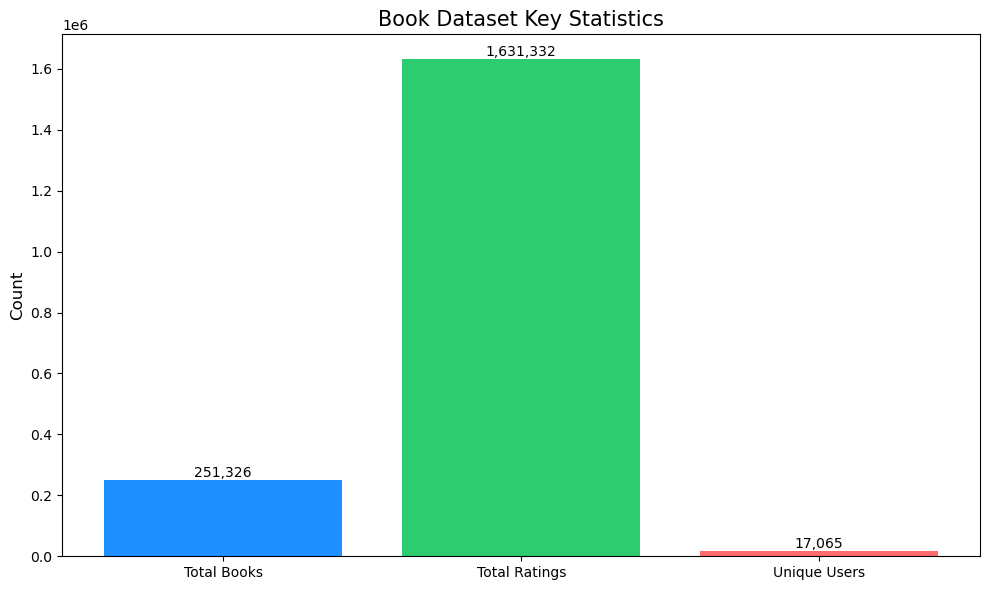

In [19]:
# Create a bar plot to visualize the key statistics
plt.figure(figsize=(10, 6))
stats = [num_books, num_ratings, unique_users]
labels = ['Total Books', 'Total Ratings', 'Unique Users']
colors = ['#1E90FF', '#2ECC71', '#FF6B6B']

plt.bar(labels, stats, color=colors)
plt.title('Book Dataset Key Statistics', fontsize=15)
plt.ylabel('Count', fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(stats):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


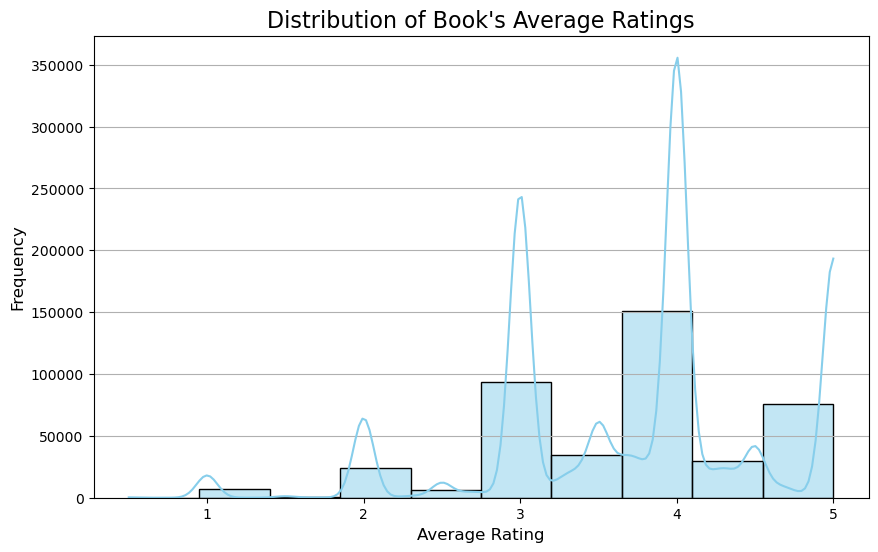

In [45]:
# preprocess the ratings to calculate the average rating per book
average_ratings = ratings_df.groupby("book_id")["rating"].mean().reset_index()
average_ratings.columns = ["book_id", "avg_rating"]

# Distribution of book's average rating by range
plt.figure(figsize=(10, 6))
sns.histplot(average_ratings["avg_rating"], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Book's Average Ratings", fontsize=16)
plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y')
plt.show()

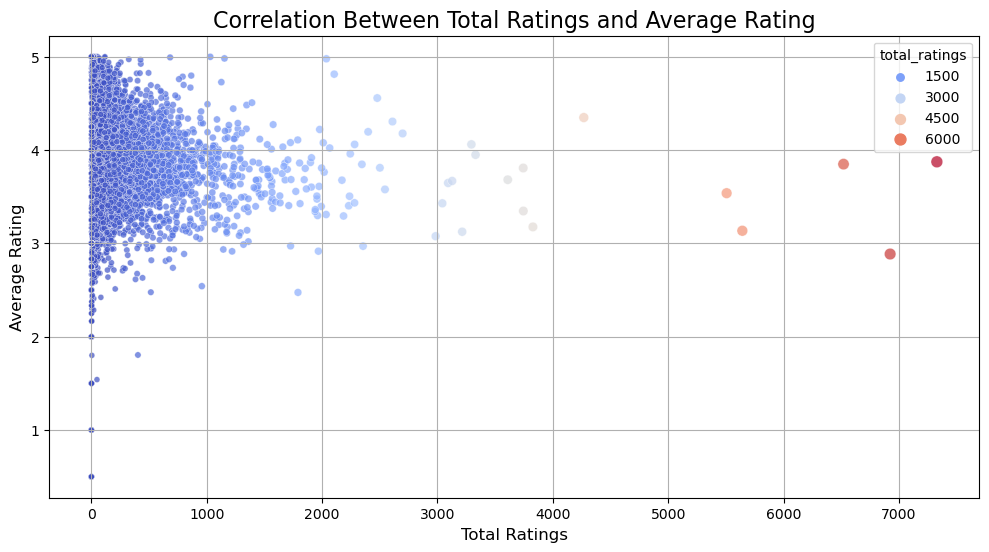

In [32]:
# Correlation of user's total ratings vs average rating
user_ratings_count = ratings_df.groupby("user_id")["rating"].count().reset_index()
user_ratings_count.columns = ["user_id", "total_ratings"]

# merge user total ratings with ratings to get user-wise average rating
user_avg_ratings = ratings_df.groupby("user_id")["rating"].mean().reset_index()
user_avg_ratings.columns = ["user_id", "avg_rating"]

data = pd.merge(user_ratings_count, user_avg_ratings, on="user_id")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x="total_ratings", y="avg_rating", alpha=0.7, hue='total_ratings', size='total_ratings', palette='coolwarm')
plt.title("Correlation Between Total Ratings and Average Rating", fontsize=16)
plt.xlabel("Total Ratings", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.grid(True)
plt.show()


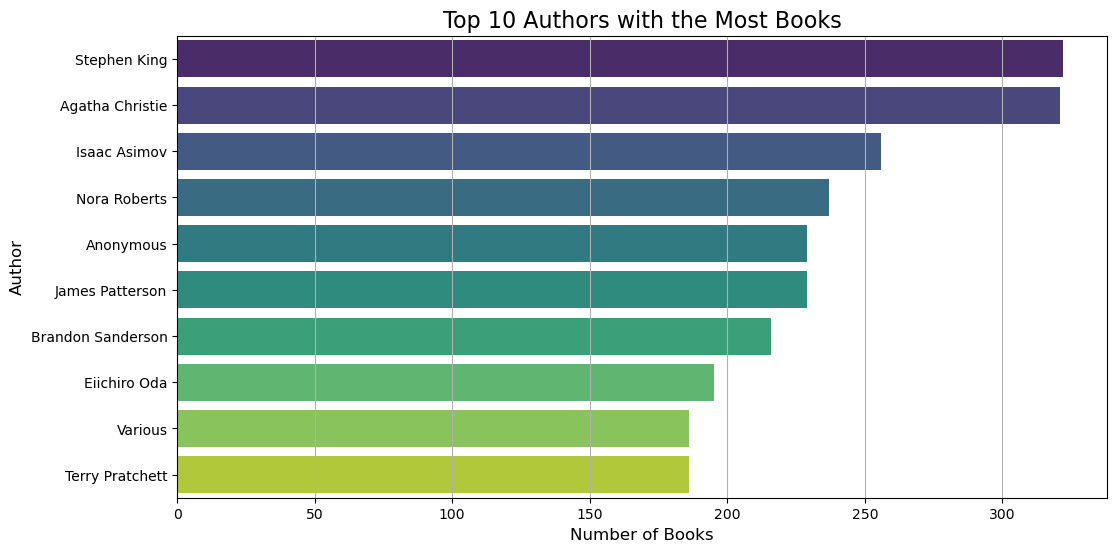

In [33]:
# top Authors with the Most Books
books_per_author = books_df.groupby("author")["id"].count().reset_index()
books_per_author.columns = ["author", "book_count"]
books_per_author = books_per_author.sort_values(by="book_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=books_per_author, x="book_count", y="author", palette="viridis")
plt.title("Top 10 Authors with the Most Books", fontsize=16)
plt.xlabel("Number of Books", fontsize=12)
plt.ylabel("Author", fontsize=12)
plt.grid(axis='x')
plt.show()


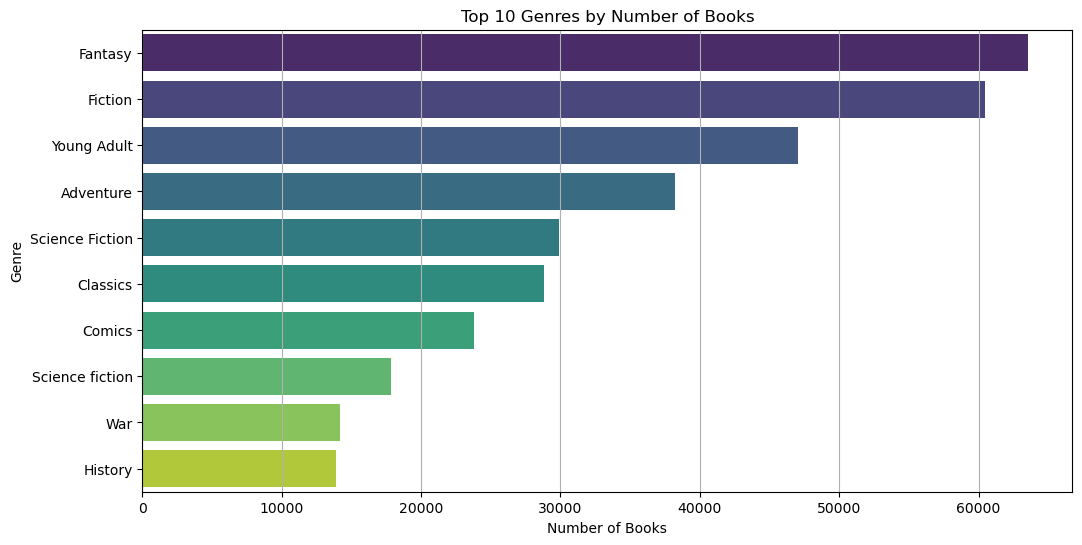

In [42]:
# Top 10 Genres by Number of Books
books_with_genres = pd.merge(books_df, books_genres_df, left_on="id", right_on="id")
genre_book_count = books_with_genres.groupby("genre")["id"].count().reset_index()
genre_book_count.columns = ["genre", "book_count"]
top_genres_by_books = genre_book_count.sort_values(by="book_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres_by_books, x="book_count", y="genre", palette="viridis")
plt.title("Top 10 Genres by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.grid(axis='x')
plt.show()

